In [93]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy as sp

In-silico depletion to ensure our guides are doing what we expect them to do before performing experimentation
-
1) All reads that matched a spacer were removed from a deeply sequenced sample 
2) then, both the in-silico depleted and the matched original sample were downsampled to the same sequencing depth 
3) comparison of genes for theoretical boost in performance
4) For this analysis we focus on the gene level and not the isoform level

In [85]:
#control RSEM TPM outs 
control = pd.read_csv('GREGOR_GUIDE/RSEM_Control_.genes.results', sep='\t', header=0)
control

,gene_id,transcript_id(s),length,effective_length,expected_count,TPM,FPKM
0,ENSG00000000003.15,"ENST00000373020.9,ENST00000494424.1,ENST000004...",2061.80,1911.80,0.0,0.00,0.00
1,ENSG00000000005.6,"ENST00000373031.5,ENST00000485971.1",873.50,723.50,0.0,0.00,0.00
2,ENSG00000000419.13,"ENST00000371582.8,ENST00000371584.8,ENST000003...",1057.37,907.37,69.0,6.27,10.44
3,ENSG00000000457.14,"ENST00000367770.5,ENST00000367771.11,ENST00000...",5514.36,5364.36,64.0,0.98,1.64
4,ENSG00000000460.17,"ENST00000286031.10,ENST00000359326.9,ENST00000...",3130.72,2980.72,19.0,0.53,0.88
...,...,...,...,...,...,...,...
60710,ENSG00000288640.1,"ENST00000675905.1,ENST00000676282.1",2725.14,2575.14,35.0,1.12,1.87
60711,ENSG00000288642.1,ENST00000674533.1,789.00,639.00,0.0,0.00,0.00
60712,ENSG00000288643.1,ENST00000509663.2,759.00,609.00,0.0,0.00,0.00
60713,ENSG00000288644.1,ENST00000675181.1,99.00,0.00,0.0,0.00,0.00


In [86]:
#depleted RSEM TPM outs 
depleted = pd.read_csv('GREGOR_GUIDE/RSEM_Depleted_.genes.results', sep='\t', header=0)
depleted

,gene_id,transcript_id(s),length,effective_length,expected_count,TPM,FPKM
0,ENSG00000000003.15,"ENST00000373020.9,ENST00000494424.1,ENST000004...",3525.00,3375.00,9.00,0.96,0.90
1,ENSG00000000005.6,"ENST00000373031.5,ENST00000485971.1",873.50,723.50,0.00,0.00,0.00
2,ENSG00000000419.13,"ENST00000371582.8,ENST00000371584.8,ENST000003...",1061.07,911.07,308.00,122.24,114.71
3,ENSG00000000457.14,"ENST00000367770.5,ENST00000367771.11,ENST00000...",3235.80,3085.80,275.00,32.22,30.24
4,ENSG00000000460.17,"ENST00000286031.10,ENST00000359326.9,ENST00000...",3240.60,3090.60,48.00,5.62,5.27
...,...,...,...,...,...,...,...
60710,ENSG00000288640.1,"ENST00000675905.1,ENST00000676282.1",2889.23,2739.23,151.49,20.00,18.77
60711,ENSG00000288642.1,ENST00000674533.1,789.00,639.00,0.00,0.00,0.00
60712,ENSG00000288643.1,ENST00000509663.2,759.00,609.00,0.00,0.00,0.00
60713,ENSG00000288644.1,ENST00000675181.1,99.00,0.00,0.00,0.00,0.00


In [87]:
#remove the added number which is the number of revision
refined_gene = []
gene_num = list(depleted['gene_id'])
for gene in gene_num:
    ensg,number = gene.split('.')
    refined_gene.append(ensg)
    
#add as column to control and depleted
depleted['gene']=refined_gene
depleted.set_index('gene', inplace=True)
control['gene']=refined_gene
control.set_index('gene', inplace=True)

#add gene names
gene_conv = pd.read_csv('GREGOR_GUIDE/Conversion_Table_Ensemble_ID_to_Gene_name.csv', index_col=0)
gene_conv_sub = gene_conv[gene_conv.index.isin(list(control.index))]

depleted['gene_name'] = gene_conv_sub['Gene_name']
control['gene_name'] = gene_conv_sub['Gene_name']

#create a merged dataset that is just TPM and gene names 
merged = pd.DataFrame()
merged['gene'] = control['gene_name']
merged['Standard_TPM'] = control['TPM']
merged['Depleted_TPM'] = depleted['TPM']

#we could also simply look at and re-calculate how many genes were down or up 
#first remove all rows that were 0 counts in both columns
merged = merged[(merged['Standard_TPM']!=0)|(merged['Depleted_TPM']!=0)]
merged['Difference'] = merged['Depleted_TPM']-merged['Standard_TPM']

#add a pseudocount of 0.1 to all TPM values
merged['Standard_TPM_non0'] = merged.Standard_TPM + 0.1
merged['Depleted_TPM_non0'] = merged.Depleted_TPM + 0.1

#create a positive or negative FC if the difference is negative
def conditions(s):
    if (s['Difference'] > 0):
        return s['Depleted_TPM_non0']/s['Standard_TPM_non0']
    else:
        return -s['Standard_TPM_non0']/s['Depleted_TPM_non0']
    
merged['FC'] = merged.apply(conditions, axis=1)
merged

,gene,Standard_TPM,Depleted_TPM,Difference,Standard_TPM_non0,Depleted_TPM_non0,FC
gene,,,,,,,
ENSG00000000003,TSPAN6,0.00,0.96,0.96,0.10,1.06,10.600000
ENSG00000000419,DPM1,6.27,122.24,115.97,6.37,122.34,19.205651
ENSG00000000457,SCYL3,0.98,32.22,31.24,1.08,32.32,29.925926
ENSG00000000460,C1orf112,0.53,5.62,5.09,0.63,5.72,9.079365
ENSG00000000938,FGR,88.47,359.28,270.81,88.57,359.38,4.057582
...,...,...,...,...,...,...,...
ENSG00000288626,ENSG00000288626,0.00,0.06,0.06,0.10,0.16,1.600000
ENSG00000288630,NaN,0.34,0.68,0.34,0.44,0.78,1.772727
ENSG00000288632,ENSG00000288632,0.29,0.00,-0.29,0.39,0.10,-3.900000


In [88]:
#count how many genes have a negative and how many genes have a positive difference?
print(str(len(merged[merged['Difference']>0]))+' genes have increased TPM in Depleted')
print(str(len(merged[merged['Difference']<0]))+' genes have decreased (depleted) TPM in Depleted')

22317 genes have increased TPM in Depleted
1863 genes have decreased (depleted) TPM in Depleted


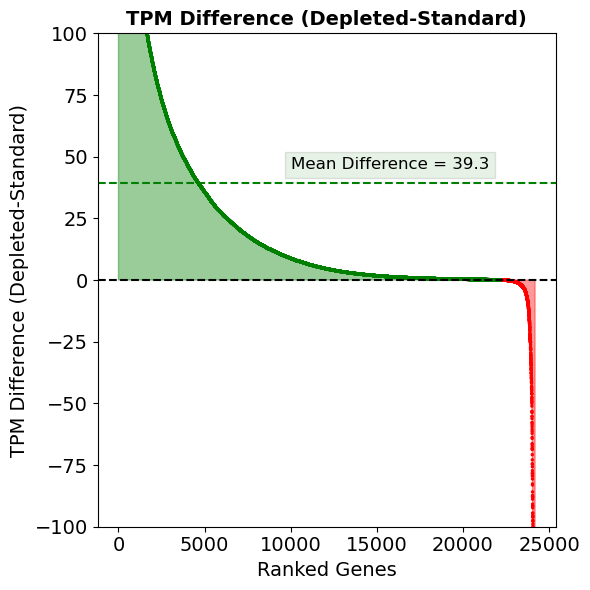

In [89]:
#sort the dataframe by the largest difference 
sort_merged = merged.sort_values(by='Difference', ascending=False)
sort_merged['OG_name'] = sort_merged.index
sort_merged = sort_merged.reset_index(drop=True)
sort_merged['Count']=sort_merged.index
sort_merged

#plot the general lines
sort_merged.plot.scatter(x='Count', y='Difference', s=2,legend=True,
                      c=np.where((sort_merged['Difference']>0), 'g', 'r'), figsize=(6,6),
                        ylim=(-100,100), fontsize=14)
plt.title('TPM Difference (Depleted-Standard)', fontdict={'fontsize': 14,
 'fontweight' : 'bold',
 'verticalalignment': 'baseline',
 'horizontalalignment': 'center'})
plt.xlabel('Ranked Genes', fontdict={'fontsize': 14})
plt.ylabel('TPM Difference (Depleted-Standard)', fontdict={'fontsize': 14})
plt.axhline(y=0, color='k', linestyle='--')

#just the positive differences
merged_pos = sort_merged[sort_merged['Difference']>0]
plt.fill_between(merged_pos.Count, merged_pos.Difference, step="pre", color='g', alpha=0.4)
merged_neg = sort_merged[sort_merged['Difference']<0]
plt.fill_between(merged_neg.Count, merged_neg.Difference, step="pre", color='r', alpha=0.4)

#add the average 
plt.axhline(y=merged_pos.Difference.mean(), color='g', linestyle='--')
plt.text(10000, 45, 'Mean Difference = '+str(round(merged_pos.Difference.mean(),1)), 
         fontsize = 12, 
         bbox = dict(facecolor = 'green', alpha = 0.1))
plt.tight_layout()
plt.savefig('GREGOR_GUIDE/insilico_difference_improvement.png',dpi=300)

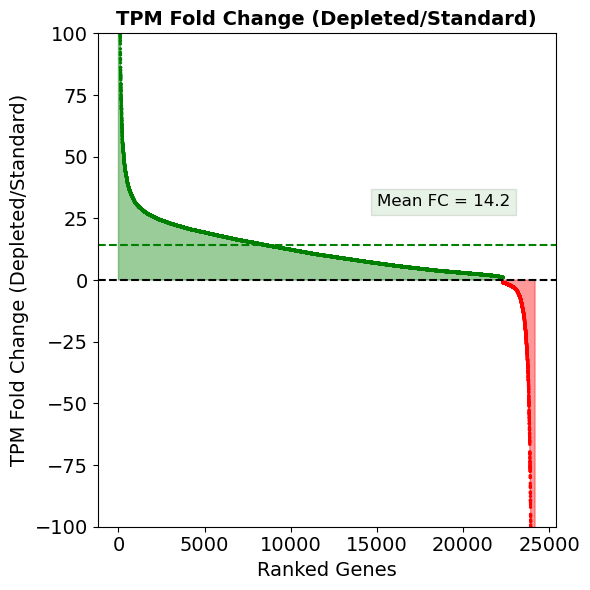

In [90]:
#rank the merged dataframe according to FC
sort_merged = merged.sort_values(by='FC', ascending=False)
sort_merged['OG_name'] = sort_merged.index
sort_merged = sort_merged.reset_index(drop=True)
sort_merged['Count']=sort_merged.index
sort_merged

sort_merged.plot.scatter(x='Count', y='FC', s=2,legend=True,
                      c=np.where((sort_merged['FC']>0), 'g', 'r'), figsize=(6,6),
                        ylim=(-100,100), fontsize=14)
plt.title('TPM Fold Change (Depleted/Standard)', fontdict={'fontsize': 14,
 'fontweight' : 'bold',
 'verticalalignment': 'baseline',
 'horizontalalignment': 'center'})
plt.xlabel('Ranked Genes', fontdict={'fontsize': 14})
plt.ylabel('TPM Fold Change (Depleted/Standard)', fontdict={'fontsize': 14})
plt.axhline(y=0, color='k', linestyle='--')

#just the positive differences
merged_pos = sort_merged[sort_merged['FC']>0]
plt.fill_between(merged_pos.Count, merged_pos.FC, step="pre", color='g', alpha=0.4)
merged_neg = sort_merged[sort_merged['FC']<0]
plt.fill_between(merged_neg.Count, merged_neg.FC, step="pre", color='r', alpha=0.4)

#add the average 
plt.axhline(y=merged_pos.FC.mean(), color='g', linestyle='--')
plt.text(15000, 30, 'Mean FC = '+str(round(merged_pos.FC.mean(),1)), 
         fontsize = 12, 
         bbox = dict(facecolor = 'green', alpha = 0.1))
plt.tight_layout()
plt.savefig('GREGOR_GUIDE/insilico_FC_improvement.png',dpi=300)

In [62]:
#how many genes were not found in the control but found in the depleted??
print(str(len(merged[(merged['Standard_TPM']==0)&(merged['Depleted_TPM']!=0)])) +
      " genes were only found in the Depleted condition")

5281 genes were only found in the Depleted condition


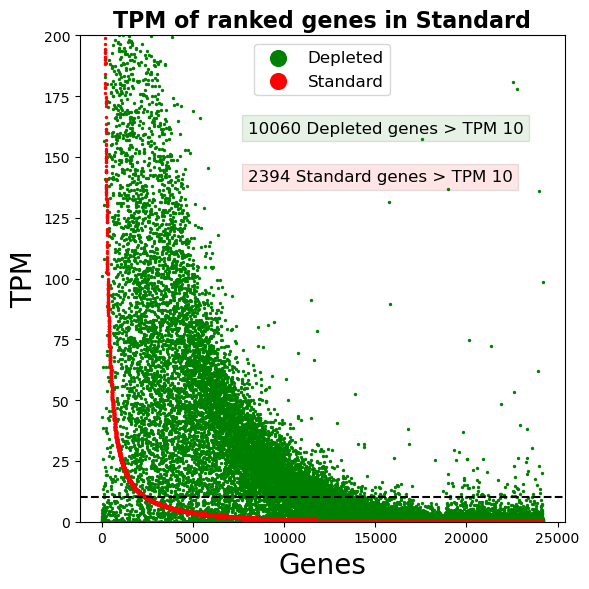

In [91]:
#what was the biggest difference in raw TPM, overlaid ontop of eachother
merged_rank = merged.sort_values(by='Standard_TPM', ascending=False)

x = [*range(0,len(merged_rank),1)]
y1 = list(merged_rank.Standard_TPM)
y2 = list(merged_rank.Depleted_TPM)

plt.figure(figsize=(6, 6))
plt.scatter(x,y2,c='g',s=2,label='Depleted')
plt.scatter(x,y1,c='r',s=2,label='Standard')
plt.ylim(0,200)
plt.legend(fontsize=12, markerscale=8)

plt.title('TPM of ranked genes in Standard', fontdict={'fontsize': 16,
 'fontweight' : 'bold',
 'verticalalignment': 'baseline',
 'horizontalalignment': 'center'})
plt.xlabel('Genes', fontdict={'fontsize': 20})
plt.ylabel('TPM', fontdict={'fontsize': 20})


#how many genes above a certain TPM threshold 
plt.axhline(y=10, color='black', linestyle='--')

plt.text(8000, 160, str(round(len(merged_rank[merged_rank['Depleted_TPM']>10]),1))+' Depleted genes > TPM 10', 
         fontsize = 12, 
         bbox = dict(facecolor = 'green', alpha = 0.1))
plt.text(8000, 140, str(round(len(merged_rank[merged_rank['Standard_TPM']>10]),1))+' Standard genes > TPM 10', 
         fontsize = 12, 
         bbox = dict(facecolor = 'red', alpha = 0.1))
plt.tight_layout()
plt.savefig('GREGOR_GUIDE/insilico_TPM_raw_improvement.png',dpi=300)

How did we affect the genes we sought to perserve?
-

In [64]:
#read in the targeted gene annotation file 
targeted = pd.read_csv('GREGOR_GUIDE/NEW_design_actual_samples/Targeted_Genes_annotation_table.txt', sep='\t', header=0)
tgenes = list(targeted['GeneSymbol'].unique())
print(len(tgenes))

preserved = pd.read_csv('GREGOR_GUIDE/NEW_design_actual_samples/Preserved_Genes_annotation_table.txt', sep='\t', header=0)
pgenes = list(preserved['GeneSymbol'].unique())
print(len(pgenes))

#some genes will be found in both because a contig might span only a single exon 
#THUS: need to find the genes that will not be touched at all 
pgenes_untouched = []
pgenes_targeted = []
for gene in pgenes:
    if gene in tgenes:
        pgenes_targeted.append(gene)
    else:
        pgenes_untouched.append(gene)

print('There are '+str(len(pgenes_untouched))+' identified genes that will not be hit by any of our guides ANYWHERE')
print('There are '+str(len(pgenes_targeted))+' out of '+str(len(tgenes))+' genes that only part of their footprint will be hit')

tgenes = [gene.strip() for gene in tgenes]
pgenes_untouched = [gene.strip() for gene in pgenes_untouched]

10977
15282
There are 6580 identified genes that will not be hit by any of our guides ANYWHERE
There are 8702 out of 10977 genes that only part of their footprint will be hit


In [65]:
#fix the spacing issues of the list of the targeted and protected genes
targeted_genes_fixed = []
for gene in tgenes:
    gene_r = gene.replace(" ", "")
    targeted_genes_fixed.append(gene_r)

protected_genes_fixed = []
for gene in pgenes_untouched:
    gene_r = gene.replace(" ", "")
    protected_genes_fixed.append(gene_r)

print(len(targeted_genes_fixed))
print(len(protected_genes_fixed))

10977
6580


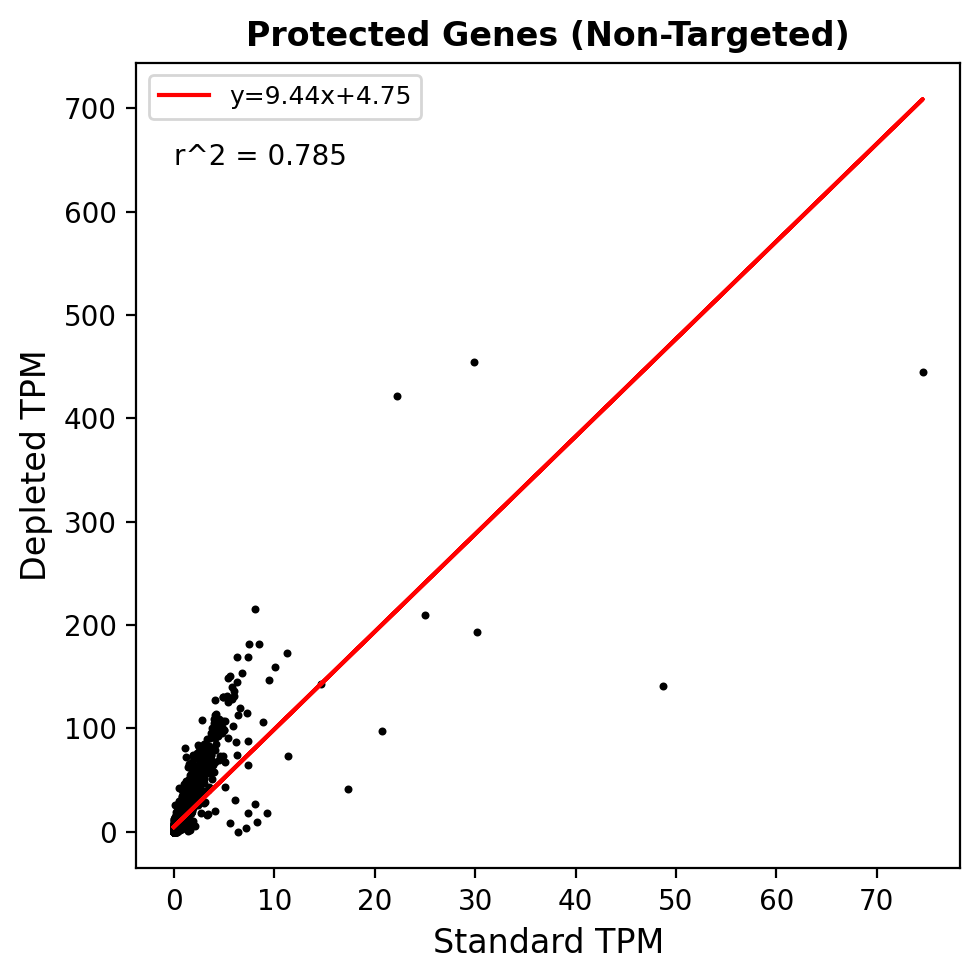

In [ ]:
#look at the protected genes and ensure we aren't altering these 
protected = merged[merged['gene'].isin(protected_genes_fixed)]
protected

x = np.array(protected.Standard_TPM)
y = np.array(protected.Depleted_TPM)

fig = plt.figure(figsize=(5,5), dpi=200)
ax = plt.subplot(111)

#regression part
slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)

line = slope*x+intercept
plt.plot(x, line, 'r', label='y={:.2f}x+{:.2f}'.format(slope,intercept))

plt.text(0.0, 645, "r^2 = "+str(round(r_value,3)))

plt.scatter(x,y, color="k", s=3.5)
plt.legend(fontsize=9)
plt.xlabel('Standard TPM',fontsize=12)
plt.ylabel('Depleted TPM',fontsize=12)
plt.title('Protected Genes (Non-Targeted)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('GREGOR_GUIDE/insilico_R2_protected_genes.png', dpi=300)
plt.show()

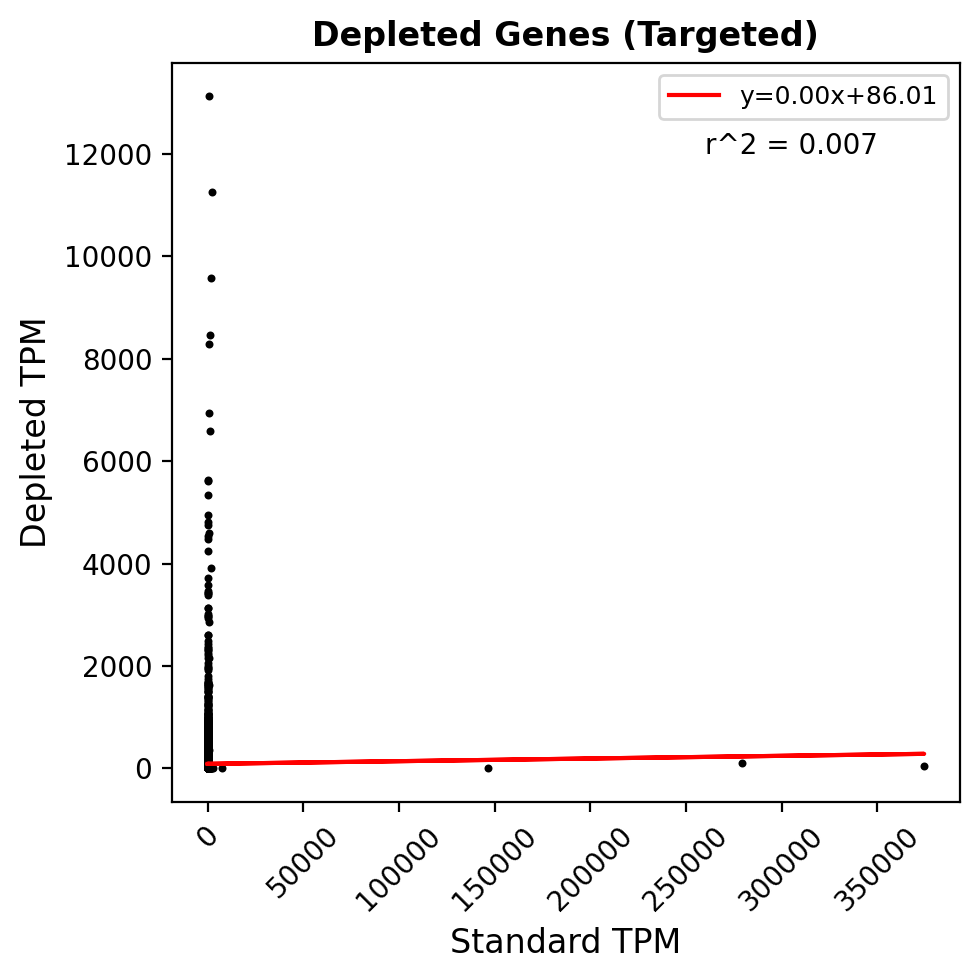

In [ ]:
#compare the gene side by side TPMs of the genes that were protected
targeted = merged[merged['gene'].isin(targeted_genes_fixed)]
targeted

x = np.array(targeted.Standard_TPM)
y = np.array(targeted.Depleted_TPM)

fig = plt.figure(figsize=(5,5), dpi=200)
ax = plt.subplot(111)

#regression part
slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)

line = slope*x+intercept
plt.plot(x, line, 'r', label='y={:.2f}x+{:.2f}'.format(slope,intercept))

plt.text(260000, 12000, "r^2 = "+str(round(r_value,3)))

plt.scatter(x,y, color="k", s=3.5)
plt.legend(fontsize=9)
plt.xlabel('Standard TPM',fontsize=12)
plt.xticks(rotation = 45)
plt.ylabel('Depleted TPM',fontsize=12)
plt.title('Depleted Genes (Targeted)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('GREGOR_GUIDE/insilico_R2_targeted_genes.png', dpi=300)
plt.show()

Now lets look at the contig level what features are altered
-


In [69]:
targeted = pd.read_csv('GREGOR_GUIDE/NEW_design_actual_samples/Targeted_homer_anno_full.txt', sep='\t', header=0)
targeted = targeted.set_index('Annotation')

preserved = pd.read_csv('GREGOR_GUIDE/NEW_design_actual_samples/Preserved_homer_anno_full.txt', sep='\t', header=0)
preserved = preserved.set_index('Annotation')

merged = targeted.join(preserved, lsuffix='_targeted', rsuffix='_preserved', how='outer')
merged

,Number of peaks_targeted,Total size (bp)_targeted,Log2 Ratio (obs/exp)_targeted,LogP enrichment (+values depleted)_targeted,Number of peaks_preserved,Total size (bp)_preserved,Log2 Ratio (obs/exp)_preserved,LogP enrichment (+values depleted)_preserved
Annotation,,,,,,,,
3UTR,3468.0,26833139,2.674,-3579.036,7073.0,26833139,0.824,-976.304
5UTR,426.0,2601483,3.016,-522.120,1849.0,2601483,2.255,-1434.886
CpG-Island,523.0,9000269,1.521,-215.218,2597.0,9000269,0.954,-466.849
DNA,1547.0,99395597,-0.379,63.432,13449.0,99395597,-0.138,69.280
DNA?,2.0,423197,-2.099,4.734,37.0,423197,-0.768,8.208
Exon,7286.0,37120946,3.277,-10380.125,26676.0,37120946,2.271,-21342.189
Intergenic,1400.0,780877963,-3.497,13043.722,40465.0,780868131,-1.523,40930.099
Intron,24947.0,656103354,0.909,-5570.199,140908.0,656103354,0.528,-11076.982
LINE,5903.0,633178497,-1.119,2803.411,73578.0,633178497,-0.358,3046.396


In [81]:
def plot_targeted_preserved_stacked(
    merged,
    targeted_col="Number of peaks_targeted",
    preserved_col="Number of peaks_preserved",
    figsize=(8, 5),
    targeted_color="steelblue",
    preserved_color="lightgrey",
    edgecolor="black",
    annotate=True
):
    """
    Plot 100% stacked bars of targeted vs preserved peak proportions by annotation.

    Parameters
    ----------
    merged : pd.DataFrame
        DataFrame indexed by annotation.
    targeted_col : str
        Column with number of targeted peaks.
    preserved_col : str
        Column with number of preserved peaks.
    figsize : tuple
        Figure size.
    targeted_color : str
        Color for targeted portion.
    preserved_color : str
        Color for preserved portion.
    edgecolor : str
        Bar edge color.
    annotate : bool
        Whether to label percentages inside bars.

    Returns
    -------
    plot_df : pd.DataFrame
        DataFrame used for plotting, including proportions.
    """
    
    plot_df = merged[[targeted_col, preserved_col]].copy()

    # remove rows with both missing or zero total
    plot_df = plot_df.dropna(subset=[targeted_col, preserved_col], how="all")
    plot_df["total"] = plot_df[targeted_col].fillna(0) + plot_df[preserved_col].fillna(0)
    plot_df = plot_df.loc[plot_df["total"] > 0].copy()

    # proportions
    plot_df["prop_targeted"] = plot_df[targeted_col].fillna(0) / plot_df["total"]
    plot_df["prop_preserved"] = plot_df[preserved_col].fillna(0) / plot_df["total"]

    # sort by highest targeted proportion
    plot_df = plot_df.sort_values("prop_targeted", ascending=False)

    # plot
    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(plot_df))

    ax.bar(
        x,
        plot_df["prop_targeted"],
        color=targeted_color,
        edgecolor=edgecolor,
        label="Targeted"
    )

    ax.bar(
        x,
        plot_df["prop_preserved"],
        bottom=plot_df["prop_targeted"],
        color=preserved_color,
        edgecolor=edgecolor,
        label="Preserved"
    )

    # formatting
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=45, ha="right")
    ax.set_ylabel("Proportion of peaks", fontsize=14)
    ax.set_xlabel("Annotation", fontsize=14)
    ax.set_ylim(0, 1)
    ax.set_title("Targeted vs Preserved peak proportions by annotation", fontsize=14, fontweight='bold')
    ax.legend(frameon=True)

    # optional percent labels
    if annotate:
        for i, (_, row) in enumerate(plot_df.iterrows()):
            pt = row["prop_targeted"]
            pp = row["prop_preserved"]

            if pt > 0.05:
                ax.text(i, pt / 2, f"{pt:.1%}", ha="center", va="center", fontsize=9)
            if pp > 0.05:
                ax.text(i, pt + pp / 2, f"{pp:.1%}", ha="center", va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig('GREGOR_GUIDE/insilico_targeted_preserved_annotation_proportions.png', dpi=300)   
    plt.show()

    return plot_df

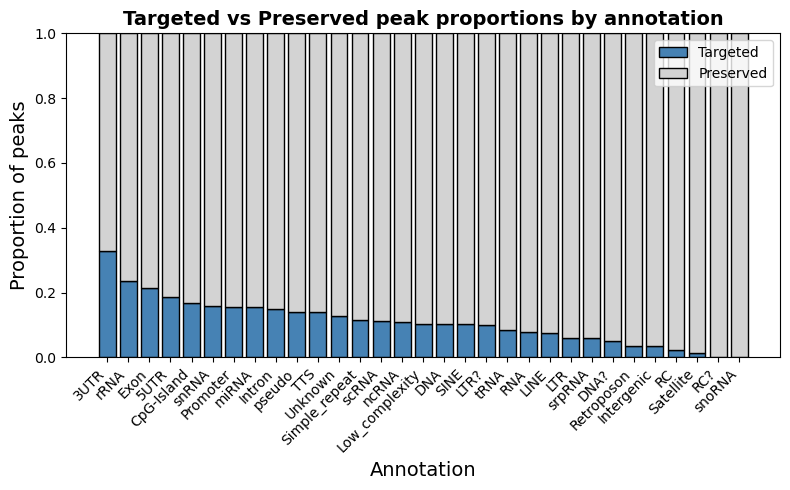

In [82]:
plot = plot_targeted_preserved_stacked(merged, annotate=False)